# Extended Wigner's friend scenario (GHZ majority vote friend)

## Imports and setup

In [1]:
import numpy as np
import itertools
import os
import pickle
import random
from enum import Enum
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from collections import defaultdict
import glob
import seaborn as sns

import qiskit
import qiskit_aer
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.compiler import transpile
from qiskit.providers import Backend
from qiskit.providers import fake_provider
from qiskit.transpiler import PassManager, CouplingMap
from qiskit.transpiler.passes import StochasticSwap, Unroller
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

DATA_PATH = os.path.join("..", "data", "majority_vote")

## Noise models

In [2]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.
    
    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model    

In [3]:
def bitflip_model(p: float) -> NoiseModel:
    """Bitflip noise model with majority vote approach.

    Args:
        p: Probability to flip.
    Returns:
        Bit-flip noise model.
    """
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
    error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

## Constants

In [4]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3

# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [5]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
BETA = np.deg2rad(175)

## Expectation values

In [6]:
def decode_results(results: dict[str, float], charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1
            
            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")
   
                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]
            
    return decoded_results

In [7]:
def double_expect(settings: list[Setting], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)

## Consider all experimental settings

In [8]:
def generate_all_experiments(
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int,
    optimize: bool = False
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilitites for all combinations of experimental settings."""
    all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]
    
    results = {}
    for alice, bob in all_experiment_combos:
        ewfs_circuit = ewfs(alice, bob, angles, beta, charlie_size, debbie_size)

        if optimize:
            ewfs_circuit = transpile(
                ewfs_circuit,
                backend=backend,
                # Use a "less" aggressive optimization to maximize routining / minimize gate merging.
                optimization_level=2,
                initial_layout=None,
            )
        
        job = qiskit.execute(
            experiments=ewfs_circuit,
            backend=backend,
            noise_model=noise_model,
            basis_gates=noise_model.basis_gates if noise_model is not None else None,
            shots=shots,
        )
        counts = job.result().get_counts()
        
        # Convert counts to probabilities.
        probabilities = {key[::-1]: value / shots for key, value in counts.items()}

        results[(alice, bob)] = probabilities
    return results

## State preparation

In [9]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [10]:
def cnot_ladder(qc: QuantumCircuit, observer: Observer, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [11]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)
    
def apply_setting(qc: QuantumCircuit, 
                  observer: Observer, 
                  setting: Setting, 
                  angle: float, 
                  observer_creg: list[int] | int, 
                  friend_qubits: int, 
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""    
    if setting is PEEK:
        # Ask friend for the outcome.
        qc.measure(friend_qubits, observer_creg)

    elif setting in [REVERSE_1, REVERSE_2]:
        cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)        

        if observer is BOB:
            qc.h(BOB)        
            qc.rz((BETA - ANGLES[1]), BOB)        
        ewfs_rotation(qc, observer, angle)            
        qc.measure(observer, observer_creg)
        
def ewfs(alice_setting: Setting, 
        bob_setting: Setting, 
        angles: list[float], 
        beta: float,
        charlie_size: int,
        debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""    
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice", "Bob", "Charlie", "Debbie"])
    ]    
    if (alice_setting == PEEK and bob_setting != PEEK):
        measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
        alice_creg = list(range(charlie_size))
        bob_creg = charlie_size
    else:
        measurement = ClassicalRegister(meas_size, name="Measurement")
        alice_creg = 0
        bob_creg = 1
        
    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = range(sys_size, (sys_size + charlie_size))
    debbie_qubits = range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size))
    
    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)
    
    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
    cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    return qc

## Sanity checks

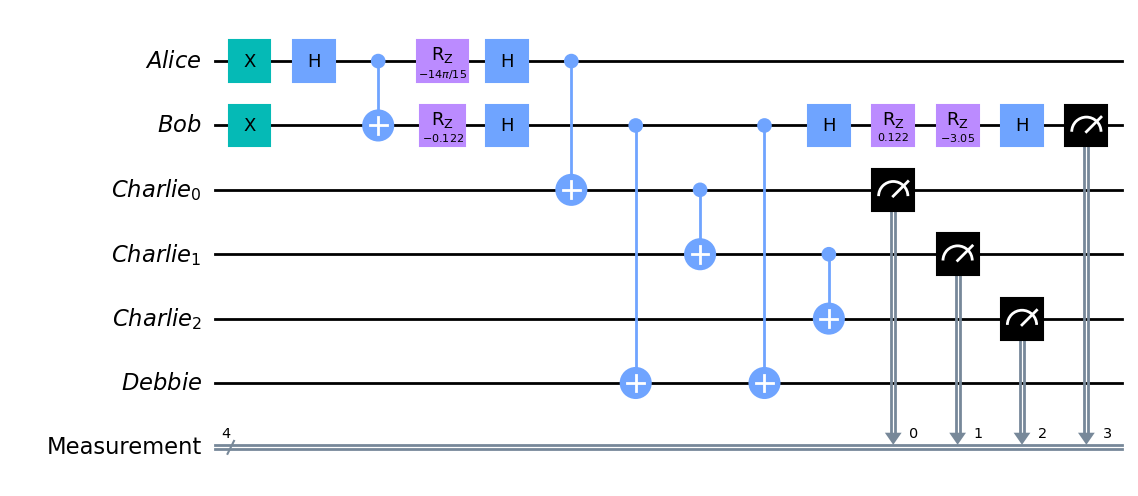

In [12]:
# Print example circuit.
charlie_size = 3
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], ANGLES, BETA, charlie_size)
qc.draw("mpl", style="default")

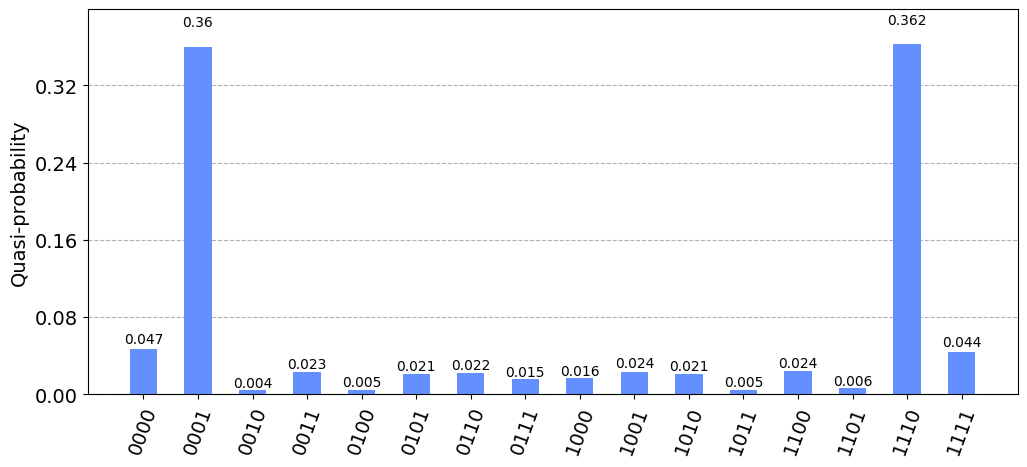

In [13]:
noise_bit_flip = bitflip_model(0.03)

job = qiskit.execute(
    experiments=qc,
    backend=qiskit.Aer.get_backend("aer_simulator"),
    noise_model=noise_bit_flip,
    basis_gates=noise_bit_flip.basis_gates if noise_bit_flip is not None else None,
    shots=1e4,
)
counts = job.result().get_counts()

# Convert counts to probabilities.
probabilities = {key[::-1]: value / 1e4 for key, value in counts.items()}

from qiskit.visualization import plot_distribution
plot_distribution(probabilities, figsize=(12, 5))

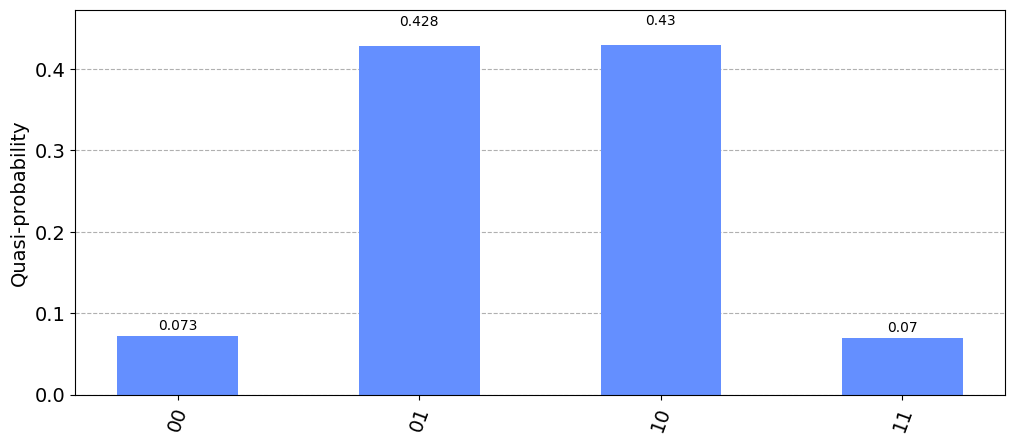

In [14]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

## File I/O

In [15]:
def save_data(
    results: dict,
    backend: Backend,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    backend_name: str = None
):
    """Writes data to a file name format of `<MACHINE_NAME>_qubits_<NUM_QUBITS>_trial_<NUM_TRIALS>_shots_<NUM_SHOTS>`."""
    if backend_name is None:
        backend_name = backend.name

    for friend_size in friend_sizes:
        qubits = friend_size

        # If not output file name is given, use this format.
        output_file_name = f"{backend_name}_qubits_{qubits}_trial_{num_trials}_shots_{shots}.pickle"
        output_path = os.path.join(DATA_PATH, output_file_name)

        print(f"Writing data to: {output_path}")
        with open(output_path, "wb") as handle:
            pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [16]:
def load_experiments(machine_name: str, friend_sizes: list[int], num_trials: int, shots: int) -> dict:
    """Load experiments from multiple files."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        for trial in range(1, num_trials+1):
            with open(os.path.join(DATA_PATH, f"{machine_name}_qubits_{friend_size}_trial_{trial}_shots_{shots}.pickle"), "rb") as file:
                results = pickle.load(file)
            violations = compute_inequalities(decode_results(results, charlie_size=friend_size, debbie_size=1))
            for key in violations:
                all_results[friend_size][key].append(violations[key])
    return all_results

## Inequalities

In [17]:
def compute_inequalities(results, verbose=False) -> dict[str, float]:
    """Compute the semi-Brukner inequalities."""
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)
    
    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2
    
    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")
        
    return {"semi_brukner": semi_brukner}

## Experiment

In [18]:
def run_experiment(
    backend: Backend,
    noise_model: NoiseModel,
    friend_sizes: list[int],
    shots: float,
    backend_name: str = None,
    num_trials: int = 1,
    verbose: bool = False,
    save: bool = False,
    optimize: bool = False,
) -> dict:
    """Run the main experiment for a specified backend."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        print(f"{friend_size=}")
        for trial in range(num_trials):
            results = generate_all_experiments(
                backend=backend,
                noise_model=noise_model,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
                debbie_size=1,
                optimize=optimize,
            )
            violations = compute_inequalities(decode_results(results, charlie_size=friend_size, debbie_size=1), verbose=verbose)
            for key in violations:
                all_results[friend_size][key].append(violations[key])
            # Save data after each trial of each friend_size
            if save:
                save_data(results=results, backend=backend, friend_sizes=[friend_size], num_trials=trial + 1, shots=shots, backend_name=backend_name)
    return all_results

## Plotting

In [42]:
def plot_results(
    ax,
    results: dict, 
    friend_sizes: list[int], 
    plot_title: str,
    plot_error_bars: bool = False,
    color: str = "tab:blue",
    label: str = None,
    show_legend: bool = False,
    marker: str = "o",
    marker_size: float = 10,
    line_width: float = 2.5,
    y_min: float = None,
    y_max: float = None,
):
    # Compute averages and standard deviations
    avg_results = {}
    std_results = {}
    for fs in results:
        avg_results[fs] = {}
        std_results[fs] = {}
        for key in results[fs]:
            avg_results[fs][key] = np.mean(results[fs][key])
            if plot_error_bars:
                std_results[fs][key] = np.std(results[fs][key])

    for i, key in enumerate(["semi_brukner"]):
        means = [np.mean(results[fs][key]) for fs in friend_sizes]
        errors = [np.std(results[fs][key]) for fs in friend_sizes] if plot_error_bars else None
        ax.plot(
            friend_sizes,
            means,
            label=label,
            marker=marker,
            markersize=marker_size,
            linestyle="-",
            linewidth=line_width,
            color=color,
        )
        if plot_error_bars:
            ax.errorbar(friend_sizes, means, yerr=errors, fmt="none", color=color, capsize=5, elinewidth=line_width)

    ax.axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
    ax.axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

    ax.set_xticks(friend_sizes)
    ax.set_title(plot_title)
    ax.grid(True)

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)    

    if show_legend:
        ax.legend()

## Plotting loaded data

In [43]:
# Load hardware data
kolkata_machine_name = "ibmq_kolkata"
kolkata_friend_sizes = range(1, 9)
kolkata_num_trials = 10
kolkata_shots = 10000
kolkata_results = load_experiments(kolkata_machine_name, kolkata_friend_sizes, kolkata_num_trials, kolkata_shots)

osaka_machine_name = "ibm_osaka"
osaka_friend_sizes = range(1, 9)
osaka_num_trials = 5
osaka_shots = 10000
osaka_results = load_experiments(osaka_machine_name, osaka_friend_sizes, osaka_num_trials, osaka_shots)

kyoto_machine_name = "ibm_kyoto"
kyoto_friend_sizes = range(1, 9)
kyoto_num_trials = 5
kyoto_shots = 10000
kyoto_results = load_experiments(kyoto_machine_name, kyoto_friend_sizes, kyoto_num_trials, kyoto_shots)

# Load fake data
fake_kolkata_machine_name = "fake_kolkata"
fake_kolkata_friend_sizes = range(1, 13)
fake_kolkata_num_trials = 10
fake_kolkata_shots = 10000
fake_kolkata_results = load_experiments(fake_kolkata_machine_name, fake_kolkata_friend_sizes, fake_kolkata_num_trials, fake_kolkata_shots)

fake_mumbai_machine_name = "fake_mumbai"
fake_mumbai_friend_sizes = range(1, 13)
fake_mumbai_num_trials = 10
fake_mumbai_shots = 10000
fake_mumbai_results = load_experiments(fake_mumbai_machine_name, fake_mumbai_friend_sizes, fake_mumbai_num_trials, fake_mumbai_shots)

fake_hanoi_machine_name = "fake_hanoi"
fake_hanoi_friend_sizes = range(1, 13)
fake_hanoi_num_trials = 10
fake_hanoi_shots = 10000
fake_hanoi_results = load_experiments(fake_hanoi_machine_name, fake_hanoi_friend_sizes, fake_hanoi_num_trials, fake_hanoi_shots)

fake_cairo_machine_name = "fake_cairo"
fake_cairo_friend_sizes = range(1, 13)
fake_cairo_num_trials = 10
fake_cairo_shots = 10000
fake_cairo_results = load_experiments(fake_cairo_machine_name, fake_cairo_friend_sizes, fake_cairo_num_trials, fake_cairo_shots)

# Load simulator data
ideal_sim_name = "ideal_simulator"
ideal_sim_friend_sizes = range(1, 13)
ideal_sim_num_trials = 10
ideal_sim_shots = 10000
ideal_sim_results = load_experiments(ideal_sim_name, ideal_sim_friend_sizes, ideal_sim_num_trials, ideal_sim_shots)

depolarizing_1perc_name = "depolarizing_1perc"
depolarizing_1perc_friend_sizes = range(1, 13)
depolarizing_1perc_num_trials = 10
depolarizing_1perc_shots = 10000
depolarizing_1perc_results = load_experiments(depolarizing_1perc_name, depolarizing_1perc_friend_sizes, depolarizing_1perc_num_trials, depolarizing_1perc_shots)

depolarizing_2perc_name = "depolarizing_2perc"
depolarizing_2perc_friend_sizes = range(1, 13)
depolarizing_2perc_num_trials = 10
depolarizing_2perc_shots = 10000
depolarizing_2perc_results = load_experiments(depolarizing_2perc_name, depolarizing_2perc_friend_sizes, depolarizing_2perc_num_trials, depolarizing_2perc_shots)

depolarizing_3perc_name = "depolarizing_3perc"
depolarizing_3perc_friend_sizes = range(1, 13)
depolarizing_3perc_num_trials = 10
depolarizing_3perc_shots = 10000
depolarizing_3perc_results = load_experiments(depolarizing_3perc_name, depolarizing_3perc_friend_sizes, depolarizing_3perc_num_trials, depolarizing_3perc_shots)

In [51]:
def calculate_branch_factor(friend_size):
    return friend_size / 2

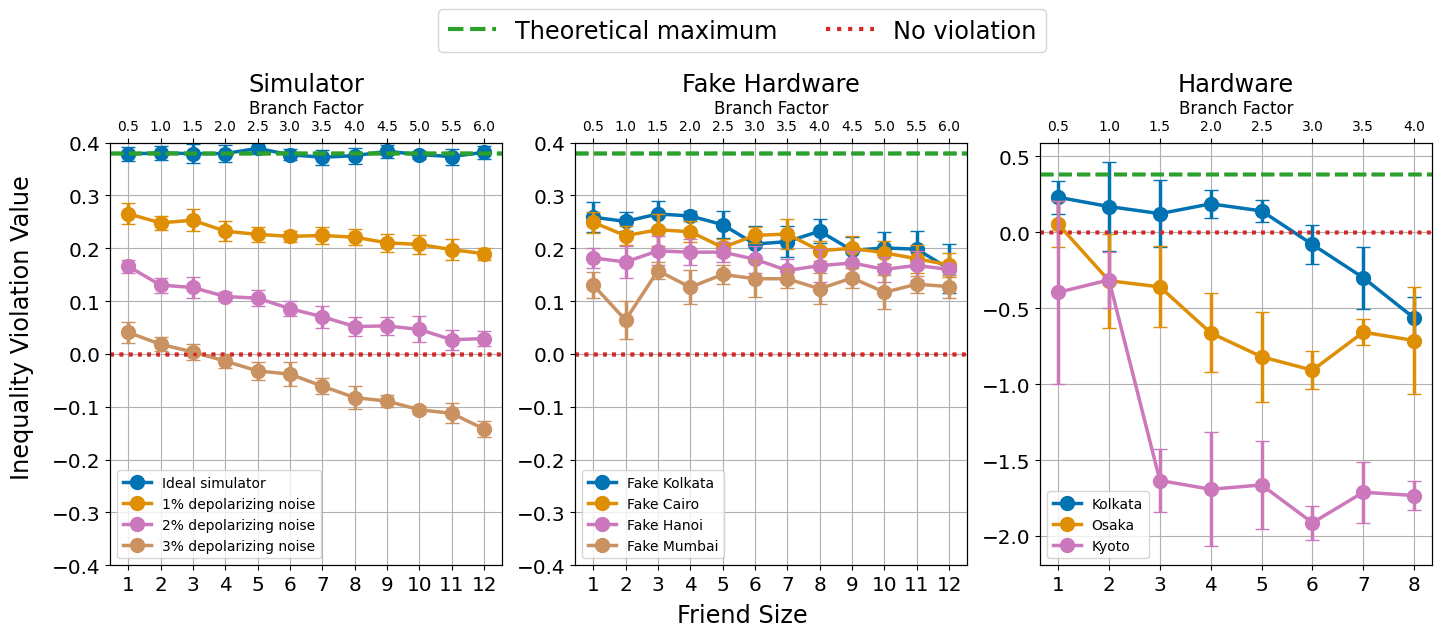

In [67]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=7)

# Simulator plots
plot_results(axs[0], ideal_sim_results, ideal_sim_friend_sizes, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-0.4, y_max=0.4)
plot_results(axs[0], depolarizing_1perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_2perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_3perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[5], label="3% depolarizing noise", show_legend=True)

# Fake hardware plots
plot_results(axs[1], fake_kolkata_results, fake_kolkata_friend_sizes, plot_error_bars=True, plot_title="Fake Kolkata", color=palette[0], label="Fake Kolkata", show_legend=True, y_min=-0.4, y_max=0.4)
plot_results(axs[1], fake_cairo_results, fake_cairo_friend_sizes, plot_error_bars=True, plot_title="Fake Cairo", color=palette[1], label="Fake Cairo", show_legend=True)
plot_results(axs[1], fake_hanoi_results, fake_hanoi_friend_sizes, plot_error_bars=True, plot_title="Fake Hanoi", color=palette[4], label="Fake Hanoi", show_legend=True)
plot_results(axs[1], fake_mumbai_results, fake_mumbai_friend_sizes, plot_error_bars=True, plot_title="Fake Mumbai", color=palette[5], label="Fake Mumbai", show_legend=True)

# Hardware plots
plot_results(axs[2], kolkata_results, kolkata_friend_sizes, plot_error_bars=True, plot_title="Kolkata", color=palette[0], label="Kolkata", show_legend=True)
plot_results(axs[2], osaka_results, osaka_friend_sizes, plot_error_bars=True, plot_title="Osaka", color=palette[1], label="Osaka", show_legend=True)
plot_results(axs[2], kyoto_results, kyoto_friend_sizes, plot_error_bars=True, plot_title="Kyoto", color=palette[4], label="Kyoto", show_legend=True)

axs[0].set_title("Simulator", fontsize="xx-large")
axs[1].set_title("Fake Hardware", fontsize="xx-large")
axs[2].set_title("Hardware", fontsize="xx-large")

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Friend Size", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Inequality Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

ax2 = axs[0].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes]
ax2.set_xlim(axs[0].get_xlim())
ax2.set_xticks(ideal_sim_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

ax2 = axs[1].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in fake_kolkata_friend_sizes]
ax2.set_xlim(axs[1].get_xlim())
ax2.set_xticks(fake_kolkata_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

ax2 = axs[2].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in kolkata_friend_sizes]
ax2.set_xlim(axs[2].get_xlim())
ax2.set_xticks(kolkata_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_hardware_comparison.pdf", bbox_inches="tight")
plt.show()

## Running experiments

### Running simulators

In [ ]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="ideal_simulator",
)

# Depolarizing noise (1%)
noise_model = depolarizing_noise_model(error=0.01)
depolarizing_1perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_1perc",    
)

# Depolarizing noise (2%)
noise_model = depolarizing_noise_model(error=0.02)
depolarizing_2perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_2perc",
)

# Depolarizing noise (3%)
noise_model = depolarizing_noise_model(error=0.03)
depolarizing_3perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_3perc",
)

### Running fake devices

In [ ]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000

# Fake Kolkata
backend = fake_provider.FakeKolkataV2()
noise_model = NoiseModel.from_backend(backend)
fake_kolkata_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
)

# Fake Hanoi
backend = fake_provider.FakeHanoiV2()
noise_model = NoiseModel.from_backend(backend)
fake_hanoi_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
)

# Fake Cairo
backend = fake_provider.FakeCairoV2()
noise_model = NoiseModel.from_backend(backend)
fake_cairo_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
)

# Fake Mumbai
backend = fake_provider.FakeMumbaiV2()
noise_model = NoiseModel.from_backend(backend)
fake_mumbai_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
)

### Running hardware

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

IBM_PROVIDER_TOKEN="f93ccee55d555d956b5bd12641edb2b79f29c28235f064dccb3cfba3109d144271ce5a31fa05b26430abe31be8e87cf50f542cdf84abe3473c2f58fa7a1f56c5"

# Save an IBM Quantum account and set it as your default account.
QiskitRuntimeService.save_account(channel="ibm_quantum", token=IBM_PROVIDER_TOKEN, set_as_default=True, overwrite=True)

# Load saved credentials
service = QiskitRuntimeService()

# Parameters for all plots
friend_sizes = range(1, 9)
num_trials = 5
shots = 10_000

In [ ]:
# Kolkata hardware data
backend = service.backend("ibmq_kolkata")
noise_model = NoiseModel.from_backend(backend)
kolkata_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)